In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from collections import deque
from scipy.stats import chisquare
import matplotlib.pyplot as plt

Клас алгоритму DBCLASD.

In [ ]:
class DBCLASD:
  def __init__(self, data, knn_n_neighbors=30):
    self.data = data
    self.n_points = data.shape[0]

    # Fit KNN model on data
    self.knn_n_neighbors = knn_n_neighbors
    self.knn = NearestNeighbors(
        n_neighbors=self.knn_n_neighbors
    ).fit(data)

    # Create labels for data with value -1 for unclustered ones
    self.labels = np.full(self.n_points, -1)

    # Variables to track current cluster and processed points' indices
    self.current_cluster = -1
    self.processed_points = set()
    self.candidates = deque()
    self.unsuccessful_candidates = deque()

  def fit(self):
    for point_idx in range(self.n_points):
      # Skip if the point is already clustered
      if self.labels[point_idx] != -1:
        continue

      # Create a new cluster for current point
      self.current_cluster += 1
      self.labels[point_idx] = self.current_cluster

      # Create a list of all points' indices in new cluster
      cluster_points = [point_idx]

      # Set lists of candidates, unsuccessfull candidates and processed points
      self.processed_points = set()
      self.candidates = deque()
      self.unsuccessful_candidates = deque()

      # Get 30 nearest neighbors
      knn_neighbors = self.knn.kneighbors(
          [self.data[point_idx]],
          self.knn_n_neighbors,
          return_distance=False
      )[0]

      # Set neighbors' clusters to current cluster if they have no cluster yet
      for neighbor_idx in knn_neighbors:
        if self.labels[neighbor_idx] == -1:
          self.labels[neighbor_idx] = self.current_cluster
          cluster_points.append(neighbor_idx)

      # Expand the cluster
      for point in cluster_points:
        answers = self.retrieve_neighborhood(point, cluster_points)
        self.update_candidates(answers)

      # Expand cluster using chi square test
      self.expand_cluster(cluster_points)

    return self.labels

  def retrieve_neighborhood(self, point_idx, cluster_points):
    # Get radius
    radius = self.calculate_radius(cluster_points)

    neighbors = self.knn.radius_neighbors(
        [self.data[point_idx]],
        radius=radius,
        return_distance=False
    )[0]

    return sorted(
        neighbors,
        key=lambda i: np.linalg.norm(self.data[i] - self.data[point_idx])
    )

  def calculate_radius(self, cluster_points):
    N = len(cluster_points)
    if N < 2:
      return 0.0

    cluster_data = self.data[cluster_points]

    # Get grid length as max nearest neighbor distance
    nn = NearestNeighbors(n_neighbors=2).fit(cluster_data)
    distances, _ = nn.kneighbors(cluster_data)
    grid_len = np.max(distances[:, -1])

    if grid_len == 0:
      return 0.0

    # Assign points to grid cells
    grid_indices = np.floor(cluster_data / grid_len).astype(int)
    unique_cells = {tuple(idx) for idx in grid_indices}

    # Area is number of unique occupied cells times cell area
    area = len(unique_cells) * (grid_len ** 2)

    # Calculate radius
    radius = 5 * np.sqrt((area / np.pi) * (1 - (1 / (N ** (1 / N)))))
    return radius

  def update_candidates(self, points):
    # Update candidates with unprocessed points only
    for point in points:
      if point not in self.processed_points:
        self.candidates.append(point)
        self.processed_points.add(point)

  def expand_cluster(self, cluster_points):
    to_continue_expanding = True
    while to_continue_expanding:
      to_continue_expanding = False

      while self.candidates:
        # Select the first candidate
        point_idx = self.candidates.popleft()

        # Skip if it is already clustered
        if self.labels[point_idx] != -1:
          continue

        # Set cluster index for the candidate
        cluster_points.append(point_idx)
        self.labels[point_idx] = self.current_cluster

        # If distance set has uniform distribution update candidates
        if self.distance_set_has_expected_distribution(cluster_points):
          answers = self.retrieve_neighborhood(point_idx, cluster_points)
          self.update_candidates(answers)
          to_continue_expanding = True

        else:
          # Unlabel the point and mark it unsuccessfull
          cluster_points.remove(point_idx)
          self.labels[point_idx] = -1
          self.unsuccessful_candidates.append(point_idx)

      # Update the candidates with unsuccessful
      self.candidates.extend(self.unsuccessful_candidates)
      self.unsuccessful_candidates.clear()

  def distance_set_has_expected_distribution(self, cluster_points, alpha=0.0001):
    # Chi square requires 30 points at least
    if len(cluster_points) < 30:
      return False

    # Compute distances to cluster centroid
    cluster_data = self.data[cluster_points]
    centroid = np.mean(cluster_data, axis=0)
    distances = np.linalg.norm(cluster_data - centroid, axis=1)

    # Bin the distances
    num_bins = min(10, int(np.sqrt(len(distances))))
    hist, bin_edges = np.histogram(distances, bins=num_bins)

    # Calculate expected frequency
    expected_freq = np.full(num_bins, len(distances) / num_bins)

    # Perform chi square test
    chi2_stat, p_value = chisquare(f_obs=hist, f_exp=expected_freq)

    # Accept if not significantly different from expected
    return p_value > alpha

Функція генерації кластерів з рівномірним розподілом даних.

In [ ]:
def generate_uniform_clusters(n_clusters=3, points_per_cluster=200, spread=1.2, seed=42):
  if seed is not None:
    np.random.seed(seed)

  data = []
  centers = np.random.uniform(0, 15, size=(n_clusters, 2))

  for center in centers:
    cluster = np.random.uniform(
        low=center - spread,
        high=center + spread,
        size=(points_per_cluster, 2)
    )
    data.append(cluster)

  return np.vstack(data)

Функція для візуалізації кластерів.

In [ ]:
def plot_clusters(data, labels=None):
  plt.figure(figsize=(8, 6))

  if labels is None:
    plt.scatter(data[:, 0], data[:, 1], s=5)
  else:
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)

    colors = plt.get_cmap("tab20", n_clusters)

    for i, c in enumerate(unique_labels):
      cluster = data[labels == c, :]
      plt.scatter(cluster[:, 0], cluster[:, 1], s=5, color=colors(i), label=f"Cluster {c}")

  plt.title("Multiple uniform clusters")
  if labels is not None and len(np.unique(labels)) <= 20:
    plt.legend(markerscale=2)
  plt.tight_layout()
  plt.show()

Приклад застосування алгоритму.

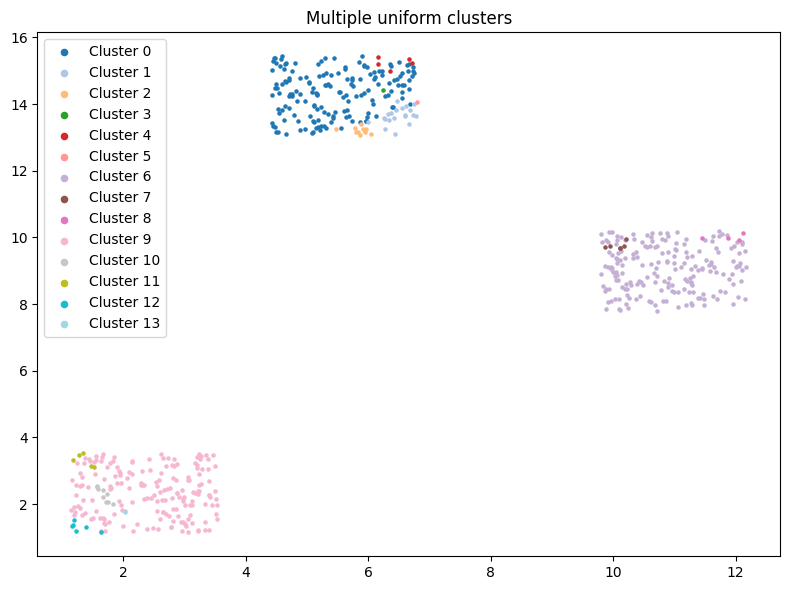

In [ ]:
data = generate_uniform_clusters()
dbclasd = DBCLASD(data)
labels = dbclasd.fit()

plot_clusters(data, labels)